# Semana 5 - Actividad 4


> Ana Sarai Zuñiga Esquivel. - AL03049128. - Ciencia de Datos. - Prof. Ricardo Alfredo Monroy Rodriguez.

### Descripción:

---

Dividida en dos partes, la actividad te guiará a través del proceso de aplicación de técnicas avanzadas de ciencia de datos para resolver problemas reales, enfocándose en dos estudios de caso: predicción de ventas según el precio y el kilometraje de los vehículos y análisis de factores de sobrevivencia en el Titanic.

---

### Objetivo:

---
Reforzar los conocimientos sobre regresión lineal múltiple y regresión logística binaria para analizar datos y generar predicciones útiles en contextos de toma de decisiones.

---

### Instrucciones:

---

### Parte 1: Predicción de ventas usando regresión lineal múltiple

En esta sección de la actividad, crearás y evaluarás un modelo de regresión lineal múltiple para predecir las ventas de los vehículos de acuerdo con el precio de venta establecido y el kilometraje de los mismos.

1. **Preparación de los datos:** Guarda la base de datos en una variable. Los datos los obtendrás de la siguiente liga: https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data/download?datasetVersionNumber=1

2. **Análisis exploratorio:** Realiza una gráfica de dispersión para verificar la relación que existe entre el precio, el kilometraje y las ventas. Para esto, utiliza pairplot de la biblioteca Seaborn, la cual te permitirá visualizar las relaciones entre estas variables.

3. **Identificación de variables:** Determina cuáles son las variables independientes y cuál es la dependiente.

4. **División de datos:** Crea los grupos de entrenamiento y de prueba para tus variables. Esta división es esencial para entrenar tu modelo con un conjunto de datos y evaluar su rendimiento con otro, asegurando así que el modelo sea capaz de generalizar a nuevos datos.

5. **Modelado:** Aplica el modelo de regresión lineal múltiple.

6. **Evaluación del modelo:** Puedes utilizar métricas como el R² (coeficiente de determinación) para entender qué tan bien el modelo se ajusta a los datos.

7. **Predicción:** Con el modelo ya entrenado y evaluado, procede a realizar las predicciones.

8. **Error cuadrático medio:** Este paso te ayudará a entender la magnitud de los errores cometidos por el modelo en sus predicciones.

9. **Conclusión:** Finalmente, elabora una conclusión con base en los resultados obtenidos. Reflexiona sobre la eficacia del modelo de regresión lineal múltiple para predecir las ventas de vehículos. Considera posibles mejoras o ajustes para futuros modelos.


### Solucion Parte 1.

---

PASO 1: Cargando datos...
Filas totales: 558837
Columnas totales: 16

Primeras filas:
   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0               

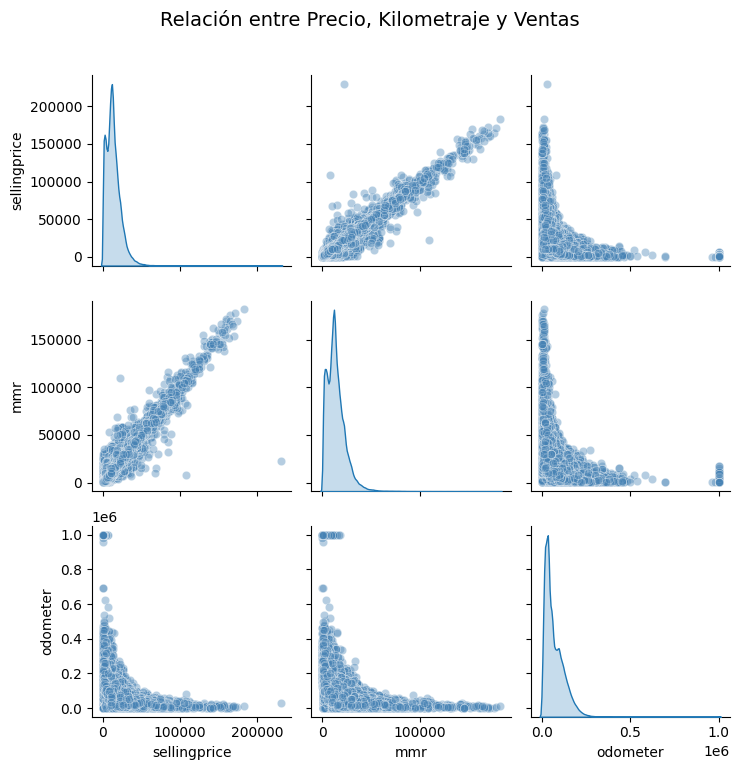

Gráfica guardada en Visualizaciones/pairplot_vehiculos.png
PASO 3: Identificación de variables
Variable dependiente (Y):  sellingprice (precio de venta)
Variables independientes (X):
   - mmr      → Precio de mercado estimado
   - odometer → Kilometraje del vehículo
PASO 4: División de datos 80% train / 20% test
Registros de entrenamiento: 446964
Registros de prueba:        111741
PASO 5: Entrenando modelo de Regresión Lineal Múltiple...
Intercepto (β₀):          99.0553
Coeficiente mmr (β₁):     0.9869
Coeficiente odometer (β₂):-0.001124

Ecuación del modelo:
  sellingprice = 99.06 + 0.9869×mmr + -0.001124×odometer
PASO 6: Evaluación del modelo
R² (coeficiente de determinación): 0.9686  →  96.86% de varianza explicada
MSE  (Error Cuadrático Medio):      2,995,581.36
RMSE (Raíz del MSE):                1,730.77


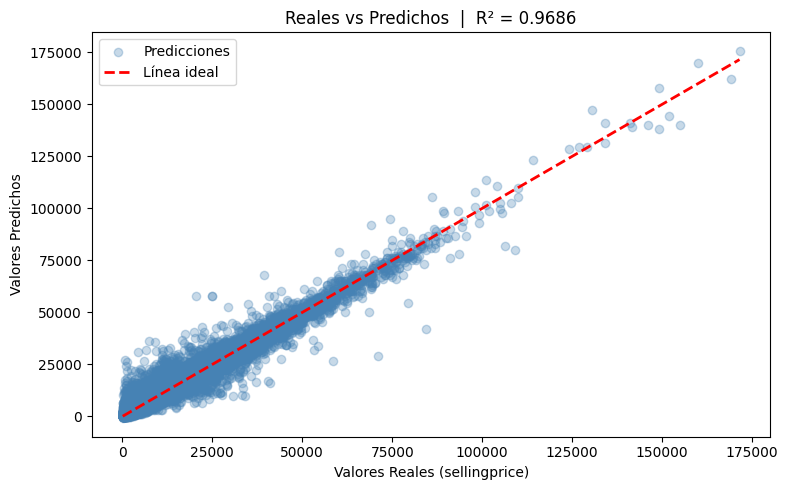

Gráfica guardada en Visualizaciones/reales_vs_predichos.png


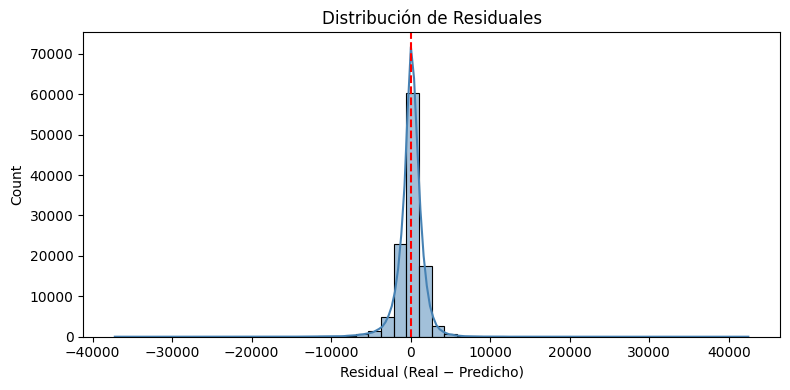

Gráfica guardada en Visualizaciones/residuales.png
PASO 7: Predicciones con nuevos datos
Ejemplos de predicción:
  Vehículo 1: mmr=$15,000 | km=50,000 → Precio estimado: $14,846.78
  Vehículo 2: mmr=$25,000 | km=80,000 → Precio estimado: $24,682.34
  Vehículo 3: mmr=$40,000 | km=30,000 → Precio estimado: $39,542.43
PASO 8: Resumen de métricas de error
  MSE  = 2,995,581.36
  RMSE = 1,730.77  ← El modelo se equivoca en promedio $1,730.77
PASO 9: CONCLUSIÓN

El modelo de Regresión Lineal Múltiple fue entrenado con 446964
registros y evaluado con 111741 registros.

Resultados:
  • R² = 0.9686 → El modelo explica el 96.9% de la variabilidad
    en el precio de venta de los vehículos.
  • RMSE = $1,730.77 → El error promedio en las predicciones es de
    aproximadamente $1,730.77 dólares.

El coeficiente de 'mmr' (0.9869) indica que por cada dólar
adicional en el precio de mercado, el precio de venta aumenta de forma
proporcional. El coeficiente de 'odometer' (-0.001124) muestra
que el kilo

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import os

# Crear carpetas necesarias automáticamente
os.makedirs('Visualizaciones', exist_ok=True)
os.makedirs('Datos', exist_ok=True)


# Paso 1. Preparacion de los datos.
print("PASO 1: Cargando datos...")

#Introducimos los datos
df = pd.read_csv('car_prices.csv')

print(f"Filas totales: {df.shape[0]}")
print(f"Columnas totales: {df.shape[1]}")
print("\nPrimeras filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)
print("\nEstadísticas descriptivas:")
print(df.describe())

# Seleccionar columnas relevantes y eliminar nulos
columnas = ['sellingprice', 'mmr', 'odometer']
df_modelo = df[columnas].dropna()

print(f"\nRegistros después de limpiar nulos: {df_modelo.shape[0]}")


# Paso 2. Analisis Exploratorio.
print("PASO 2: Análisis exploratorio...")

sns.pairplot(
    df_modelo,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 'color': 'steelblue'}
)
plt.suptitle('Relación entre Precio, Kilometraje y Ventas', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('Visualizaciones/pairplot_vehiculos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en Visualizaciones/pairplot_vehiculos.png")

# Paso 3. Identificacion de Variables.
print("PASO 3: Identificación de variables")


# Variable dependiente (Y): sellingprice — lo que queremos predecir
# Variables independientes (X): mmr (precio de mercado) y odometer (kilometraje)

X = df_modelo[['mmr', 'odometer']]   # Variables independientes
y = df_modelo['sellingprice']        # Variable dependiente

print("Variable dependiente (Y):  sellingprice (precio de venta)")
print("Variables independientes (X):")
print("   - mmr      → Precio de mercado estimado")
print("   - odometer → Kilometraje del vehículo")

#Paso 4. División de datos
print("PASO 4: División de datos 80% train / 20% test")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Registros de entrenamiento: {X_train.shape[0]}")
print(f"Registros de prueba:        {X_test.shape[0]}")

#Paso 5. Modelado.

print("PASO 5: Entrenando modelo de Regresión Lineal Múltiple...")


modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(f"Intercepto (β₀):          {modelo.intercept_:.4f}")
print(f"Coeficiente mmr (β₁):     {modelo.coef_[0]:.4f}")
print(f"Coeficiente odometer (β₂):{modelo.coef_[1]:.6f}")
print("\nEcuación del modelo:")
print(f"  sellingprice = {modelo.intercept_:.2f} "
      f"+ {modelo.coef_[0]:.4f}×mmr "
      f"+ {modelo.coef_[1]:.6f}×odometer")

#Paso 6. Evaluación del modelo
print("PASO 6: Evaluación del modelo")


y_pred = modelo.predict(X_test)

r2    = r2_score(y_test, y_pred)
mse   = mean_squared_error(y_test, y_pred)
rmse  = np.sqrt(mse)

print(f"R² (coeficiente de determinación): {r2:.4f}  →  {r2*100:.2f}% de varianza explicada")
print(f"MSE  (Error Cuadrático Medio):      {mse:,.2f}")
print(f"RMSE (Raíz del MSE):                {rmse:,.2f}")

# Gráfica: Valores reales vs predichos
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', label='Predicciones')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Línea ideal')
plt.xlabel('Valores Reales (sellingprice)')
plt.ylabel('Valores Predichos')
plt.title(f'Reales vs Predichos  |  R² = {r2:.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('Visualizaciones/reales_vs_predichos.png', dpi=150)
plt.show()
print("Gráfica guardada en Visualizaciones/reales_vs_predichos.png")

# Gráfica: Distribución de residuales
residuales = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuales, bins=50, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (Real − Predicho)')
plt.title('Distribución de Residuales')
plt.tight_layout()
plt.savefig('Visualizaciones/residuales.png', dpi=150)
plt.show()
print("Gráfica guardada en Visualizaciones/residuales.png")

#Paso 7. Predicción de nuevos datos.
print("PASO 7: Predicciones con nuevos datos")


nuevos_datos = pd.DataFrame({
    'mmr':      [15000, 25000, 40000],
    'odometer': [50000, 80000, 30000]
})

predicciones = modelo.predict(nuevos_datos)

print("Ejemplos de predicción:")
for i, pred in enumerate(predicciones):
    print(f"  Vehículo {i+1}: mmr=${nuevos_datos['mmr'][i]:,} | "
          f"km={nuevos_datos['odometer'][i]:,} → "
          f"Precio estimado: ${pred:,.2f}")

#Paso 8. Error cuadratico medio

print("PASO 8: Resumen de métricas de error")

print(f"  MSE  = {mse:,.2f}")
print(f"  RMSE = {rmse:,.2f}  ← El modelo se equivoca en promedio ${rmse:,.2f}")

#Paso 9. Conclusion
print("PASO 9: CONCLUSIÓN")
conclusion = f"""
El modelo de Regresión Lineal Múltiple fue entrenado con {X_train.shape[0]}
registros y evaluado con {X_test.shape[0]} registros.

Resultados:
  • R² = {r2:.4f} → El modelo explica el {r2*100:.1f}% de la variabilidad
    en el precio de venta de los vehículos.
  • RMSE = ${rmse:,.2f} → El error promedio en las predicciones es de
    aproximadamente ${rmse:,.2f} dólares.

El coeficiente de 'mmr' ({modelo.coef_[0]:.4f}) indica que por cada dólar
adicional en el precio de mercado, el precio de venta aumenta de forma
proporcional. El coeficiente de 'odometer' ({modelo.coef_[1]:.6f}) muestra
que el kilometraje tiene una relación negativa/positiva con el precio.

Posibles mejoras:
  1. Incluir más variables (año, marca, condición del vehículo).
  2. Aplicar normalización o estandarización de variables.
  3. Explorar modelos más complejos (Random Forest, Gradient Boosting).
"""
print(conclusion)

### Parte 2: Análisis de sobrevivencia en el Titanic con regresión logística binaria

Esta sección de la actividad se enfoca en la creación y evaluación de un modelo de regresión logística binaria. El objetivo principal será determinar las variables más significativas para predecir la sobrevivencia de los pasajeros del Titanic.

1. **Preparación de los datos:** Guarda la base de datos en una variable. Los datos los obtendrás de la siguiente liga: https://www.openml.org/data/get_csv/16826755/phpMYEkMl.

2. **Limpieza de datos:** Examina las columnas disponibles en tu conjunto de datos y decide cuáles no son necesarias para tu análisis, elimina las que no consideres necesarias. Además, identifica los datos nulos que tengas y elimínalos.

3. **Conversión de variables a su formato correcto:** Dependiendo de las variables en tu conjunto de datos, es posible que necesites convertir algunas de ellas a un tipo de dato más apropiado, como convertir variables categóricas a tipo 'category' o ajustar las fechas a un formato de fecha y hora.

4. **Visualización de datos:** Analiza los datos de forma gráfica para verificar que existe una relación entre la variable dependiente y la independiente.

5. **Prueba t-test:** Esta puede ayudarte a entender si las diferencias en las medias de dos grupos son estadísticamente significativas.

6. **División de datos:** Divide los datos en variables de prueba y de entrenamiento. Esto es crucial para entrenar el modelo y luego evaluar su capacidad para generalizar a nuevos datos.

7. **Creación del modelo:** Utiliza las clases vistas en la explicación de los temas para que puedas crear tu modelo.

8. **Estimación de los coeficientes y los odds ratio:** Una vez que entrenaste el modelo, el siguiente paso es interpretar los resultados. Esto se hace mediante la estimación de los coeficientes, los cuales te indicarán la fuerza y dirección de la relación entre cada variable independiente y la variable dependiente.

9. **Conclusión de tus resultados:** Formula una conclusión sobre tus hallazgos. Considera cuáles variables tienen mayor impacto en la probabilidad de sobrevivencia en el Titanic y la efectividad general de tu modelo para predecir la sobrevivencia. Reflexiona sobre posibles mejoras o ajustes para el modelo.

### Solucion Parte 2.

---

PASO 1: Cargando datos del Titanic...
Filas: 1309  |  Columnas: 14

Columnas disponibles:
['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

Primeras filas:
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26  

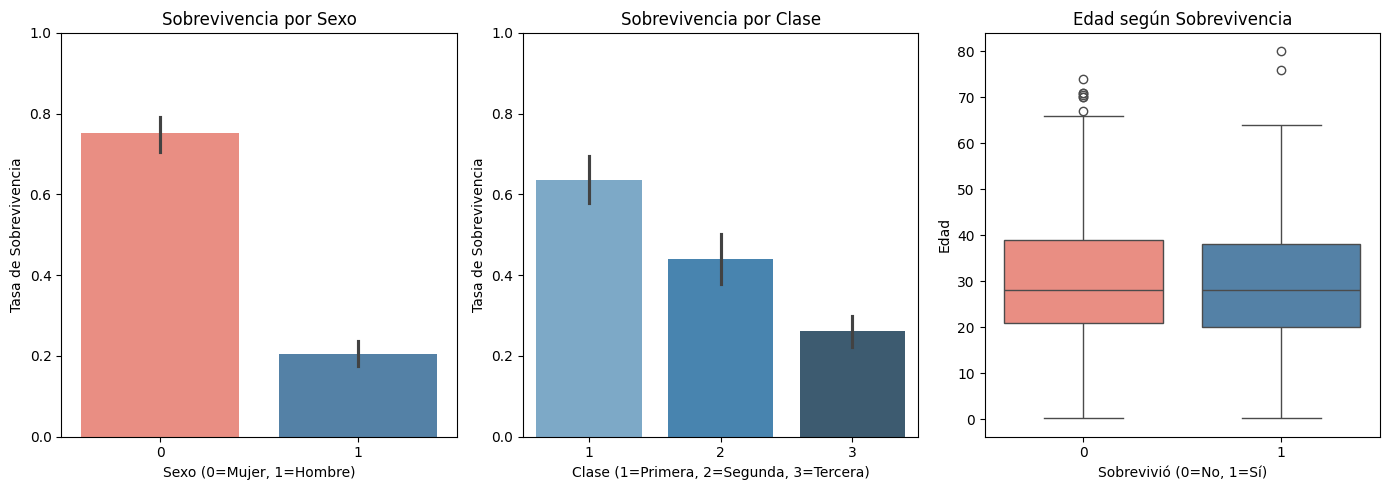

Gráfica guardada en Visualizaciones/titanic_exploratorio.png

PASO 5: Prueba T-test
Edad media — Sobrevivientes:     28.82 años
Edad media — No sobrevivientes:  30.50 años

Estadístico t:  -1.8555
p-valor:        0.0638
→ Diferencia NO significativa (p ≥ 0.05): la edad no influye significativamente.

Tasa de sobrevivencia — Hombres: 0.2055
Tasa de sobrevivencia — Mujeres: 0.7513
t = -20.5028  |  p = 0.000000
→ El sexo SÍ tiene un efecto estadísticamente significativo.

PASO 6: División de datos 80% train / 20% test
Variables independientes: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
Variable dependiente:     survived

Registros entrenamiento: 834
Registros prueba:        209

PASO 7: Entrenando modelo de Regresión Logística...
Exactitud del modelo (Accuracy): 0.7751  →  77.5%

Reporte de clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.78      0.87      0.82       125
   Sobrevivió       0.77      0.63      0.69        84

     accura

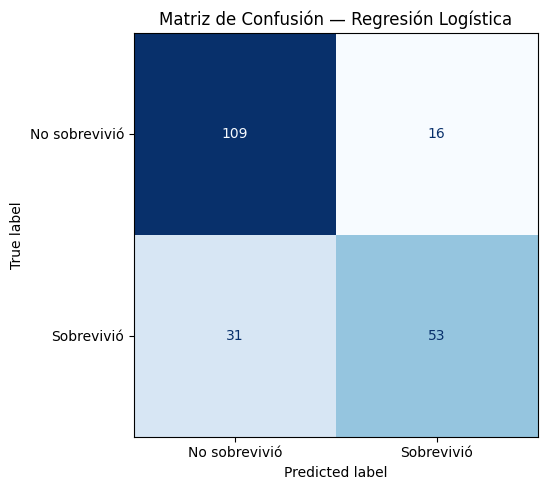

Gráfica guardada en Visualizaciones/matriz_confusion.png

PASO 8: Coeficientes y Odds Ratio
Variable  Coeficiente  Odds Ratio
   parch     0.106183    1.112025
    fare     0.001395    1.001396
     age    -0.042647    0.958249
   sibsp    -0.458269    0.632377
  pclass    -1.169060    0.310659
     sex    -2.566516    0.076803

Interpretación:
  OR > 1 → aumenta la probabilidad de sobrevivir
  OR < 1 → disminuye la probabilidad de sobrevivir
  OR = 1 → no tiene efecto


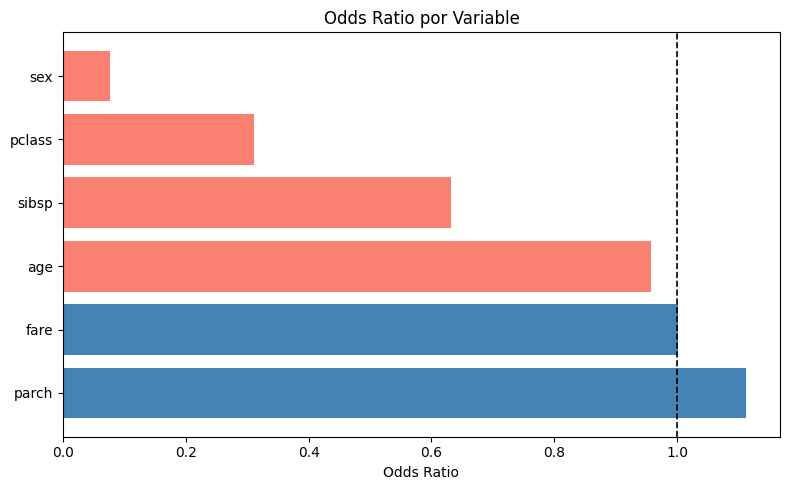

Gráfica guardada en Visualizaciones/odds_ratio.png

PASO 9: CONCLUSIÓN

El modelo de Regresión Logística Binaria fue entrenado con 834
registros y evaluado con 209 registros.

Resultados:
  • Exactitud = 77.5% → el modelo clasifica correctamente
    77.5% de los pasajeros.

  • La variable con MAYOR impacto positivo en sobrevivencia es:
    'parch' (OR = 1.1120)

  • La variable con MAYOR impacto negativo en sobrevivencia es:
    'sex' (OR = 0.0768)

  • El t-test confirmó que el sexo tiene una diferencia estadísticamente
    significativa: las mujeres tuvieron una tasa de sobrevivencia mucho
    mayor que los hombres.

Posibles mejoras:
  1. Aplicar ingeniería de características (ej. título del nombre).
  2. Manejar valores nulos con imputación en lugar de eliminarlos.
  3. Probar modelos como Random Forest o XGBoost para mejorar la exactitud.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
import warnings
import os
warnings.filterwarnings('ignore')

os.makedirs('Visualizaciones', exist_ok=True)

# PASO 1: PREPARACIÓN DE LOS DATOS
print("PASO 1: Cargando datos del Titanic...")

url = 'https://www.openml.org/data/get_csv/16826755/phpMYEkMl'
df = pd.read_csv(url, na_values=['?'])  

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print("\nColumnas disponibles:")
print(df.columns.tolist())
print("\nPrimeras filas:")
print(df.head())
print("\nValores nulos por columna:")
print(df.isnull().sum())

# PASO 2: LIMPIEZA DE DATOS
print("\nPASO 2: Limpieza de datos")

columnas_a_eliminar = ['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest']
df = df.drop(columns=[c for c in columnas_a_eliminar if c in df.columns])

print("Columnas eliminadas:", columnas_a_eliminar)
print(f"\nColumnas restantes: {df.columns.tolist()}")

df = df.dropna()
print(f"\nRegistros después de eliminar nulos: {df.shape[0]}")

# PASO 3: CONVERSIÓN DE VARIABLES
print("\nPASO 3: Conversión de variables")

df['survived']  = df['survived'].astype(int)
df['sex']       = df['sex'].map({'female': 0, 'male': 1})
df['pclass']    = df['pclass'].astype('category')
df['embarked']  = df['embarked'].map({'C': 0, 'Q': 1, 'S': 2})
df['age']       = pd.to_numeric(df['age'], errors='coerce')

print("  sex      → female=0, male=1")
print("  pclass   → tipo categoría")
print("  embarked → C=0, Q=1, S=2")
print("\nTipos de datos finales:")
print(df.dtypes)

# PASO 4: VISUALIZACIÓN DE DATOS
print("\nPASO 4: Visualización de datos")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.barplot(x='sex', y='survived', data=df, ax=axes[0],
            palette=['salmon', 'steelblue'])
axes[0].set_title('Sobrevivencia por Sexo')
axes[0].set_xlabel('Sexo (0=Mujer, 1=Hombre)')
axes[0].set_ylabel('Tasa de Sobrevivencia')
axes[0].set_ylim(0, 1)

sns.barplot(x='pclass', y='survived', data=df, ax=axes[1],
            palette='Blues_d')
axes[1].set_title('Sobrevivencia por Clase')
axes[1].set_xlabel('Clase (1=Primera, 2=Segunda, 3=Tercera)')
axes[1].set_ylabel('Tasa de Sobrevivencia')
axes[1].set_ylim(0, 1)


sns.boxplot(x='survived', y='age', data=df, ax=axes[2],
            palette=['salmon', 'steelblue'])
axes[2].set_title('Edad según Sobrevivencia')
axes[2].set_xlabel('Sobrevivió (0=No, 1=Sí)')
axes[2].set_ylabel('Edad')

plt.tight_layout()
plt.savefig('Visualizaciones/titanic_exploratorio.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en Visualizaciones/titanic_exploratorio.png")

# PASO 5: PRUEBA T-TEST
print("\nPASO 5: Prueba T-test")

sobrevivientes    = df[df['survived'] == 1]['age']
no_sobrevivientes = df[df['survived'] == 0]['age']

t_stat, p_valor = stats.ttest_ind(sobrevivientes, no_sobrevivientes)

print(f"Edad media — Sobrevivientes:     {sobrevivientes.mean():.2f} años")
print(f"Edad media — No sobrevivientes:  {no_sobrevivientes.mean():.2f} años")
print(f"\nEstadístico t:  {t_stat:.4f}")
print(f"p-valor:        {p_valor:.4f}")

if p_valor < 0.05:
    print("→ Diferencia SIGNIFICATIVA (p < 0.05): la edad influye en la sobrevivencia.")
else:
    print("→ Diferencia NO significativa (p ≥ 0.05): la edad no influye significativamente.")

hombres = df[df['sex'] == 1]['survived']
mujeres = df[df['sex'] == 0]['survived']
t2, p2  = stats.ttest_ind(hombres, mujeres)

print(f"\nTasa de sobrevivencia — Hombres: {hombres.mean():.4f}")
print(f"Tasa de sobrevivencia — Mujeres: {mujeres.mean():.4f}")
print(f"t = {t2:.4f}  |  p = {p2:.6f}")
if p2 < 0.05:
    print("→ El sexo SÍ tiene un efecto estadísticamente significativo.")

# PASO 6: DIVISIÓN DE DATOS
print("\nPASO 6: División de datos 80% train / 20% test")

variables = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
df['pclass'] = df['pclass'].astype(int)

X = df[variables]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Variables independientes: {variables}")
print(f"Variable dependiente:     survived")
print(f"\nRegistros entrenamiento: {X_train.shape[0]}")
print(f"Registros prueba:        {X_test.shape[0]}")

# PASO 7: CREACIÓN DEL MODELO
print("\nPASO 7: Entrenando modelo de Regresión Logística...")

modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_train, y_train)

y_pred   = modelo_log.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Exactitud del modelo (Accuracy): {accuracy:.4f}  →  {accuracy*100:.1f}%")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No sobrevivió', 'Sobrevivió']))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No sobrevivió', 'Sobrevivió'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística')
plt.tight_layout()
plt.savefig('Visualizaciones/matriz_confusion.png', dpi=150)
plt.show()
print("Gráfica guardada en Visualizaciones/matriz_confusion.png")

# PASO 8: COEFICIENTES Y ODDS RATIO
print("\nPASO 8: Coeficientes y Odds Ratio")

coeficientes = modelo_log.coef_[0]
odds_ratio   = np.exp(coeficientes)

tabla = pd.DataFrame({
    'Variable':    variables,
    'Coeficiente': coeficientes,
    'Odds Ratio':  odds_ratio
})
tabla = tabla.sort_values('Odds Ratio', ascending=False)

print(tabla.to_string(index=False))
print("\nInterpretación:")
print("  OR > 1 → aumenta la probabilidad de sobrevivir")
print("  OR < 1 → disminuye la probabilidad de sobrevivir")
print("  OR = 1 → no tiene efecto")

plt.figure(figsize=(8, 5))
colors = ['steelblue' if o > 1 else 'salmon' for o in tabla['Odds Ratio']]
plt.barh(tabla['Variable'], tabla['Odds Ratio'], color=colors)
plt.axvline(1, color='black', linestyle='--', linewidth=1.2)
plt.xlabel('Odds Ratio')
plt.title('Odds Ratio por Variable')
plt.tight_layout()
plt.savefig('Visualizaciones/odds_ratio.png', dpi=150)
plt.show()
print("Gráfica guardada en Visualizaciones/odds_ratio.png")

# PASO 9: CONCLUSIÓN
print("\nPASO 9: CONCLUSIÓN")

var_mayor_impacto = tabla.iloc[0]['Variable']
var_menor_impacto = tabla.iloc[-1]['Variable']

conclusion = f"""
El modelo de Regresión Logística Binaria fue entrenado con {X_train.shape[0]}
registros y evaluado con {X_test.shape[0]} registros.

Resultados:
  • Exactitud = {accuracy*100:.1f}% → el modelo clasifica correctamente
    {accuracy*100:.1f}% de los pasajeros.

  • La variable con MAYOR impacto positivo en sobrevivencia es:
    '{var_mayor_impacto}' (OR = {tabla.iloc[0]['Odds Ratio']:.4f})

  • La variable con MAYOR impacto negativo en sobrevivencia es:
    '{var_menor_impacto}' (OR = {tabla.iloc[-1]['Odds Ratio']:.4f})

  • El t-test confirmó que el sexo tiene una diferencia estadísticamente
    significativa: las mujeres tuvieron una tasa de sobrevivencia mucho
    mayor que los hombres.

Posibles mejoras:
  1. Aplicar ingeniería de características (ej. título del nombre).
  2. Manejar valores nulos con imputación en lugar de eliminarlos.
  3. Probar modelos como Random Forest o XGBoost para mejorar la exactitud.
"""
print(conclusion)